In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('../data/final/monthly_training_dataset_FINAL.csv', na_values=['NA'])

print("Shape:", df.shape)
df.head()

Shape: (244, 12)


,Municipality,Financial_Year,Calendar_Year,Month,Rainfall_Extreme_Precip_Index,Rainfall_Lag1,Rainfall_Roll3,RM_Actual_R000,NRW_Percent,Water_Losses_Rmillion,Flood_Label_HighPlusProxy,Core_Complete
0,Johannesburg,2015/16,2016,1,-0.50,NaN,-0.50,NaN,NaN,NaN,N,N
1,Johannesburg,2015/16,2016,2,-0.64,-0.50,-1.14,NaN,NaN,NaN,N,N
2,Johannesburg,2015/16,2016,3,1.36,-0.64,0.22,NaN,NaN,NaN,N,N
3,Johannesburg,2016/17,2016,4,-0.61,1.36,0.11,NaN,40.3,359.0,N,N
4,Johannesburg,2016/17,2016,5,1.17,-0.61,1.92,NaN,40.3,359.0,N,N


In [2]:
# check column types and how many values are missing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Municipality                   244 non-null    str    
 1   Financial_Year                 244 non-null    str    
 2   Calendar_Year                  244 non-null    int64  
 3   Month                          244 non-null    int64  
 4   Rainfall_Extreme_Precip_Index  244 non-null    float64
 5   Rainfall_Lag1                  242 non-null    float64
 6   Rainfall_Roll3                 244 non-null    float64
 7   RM_Actual_R000                 96 non-null     float64
 8   NRW_Percent                    180 non-null    float64
 9   Water_Losses_Rmillion          120 non-null    float64
 10  Flood_Label_HighPlusProxy      244 non-null    str    
 11  Core_Complete                  244 non-null    str    
dtypes: float64(6), int64(2), str(4)
memory usage: 23.0 KB


In [3]:
# making sure that "NA" is read as missing
print(df.isin(['NA']).sum())

Municipality                     0
Financial_Year                   0
Calendar_Year                    0
Month                            0
Rainfall_Extreme_Precip_Index    0
Rainfall_Lag1                    0
Rainfall_Roll3                   0
RM_Actual_R000                   0
NRW_Percent                      0
Water_Losses_Rmillion            0
Flood_Label_HighPlusProxy        0
Core_Complete                    0
dtype: int64


In [4]:
# missing values per column
print(df.isnull().sum())

Municipality                       0
Financial_Year                     0
Calendar_Year                      0
Month                              0
Rainfall_Extreme_Precip_Index      0
Rainfall_Lag1                      2
Rainfall_Roll3                     0
RM_Actual_R000                   148
NRW_Percent                       64
Water_Losses_Rmillion            124
Flood_Label_HighPlusProxy          0
Core_Complete                      0
dtype: int64


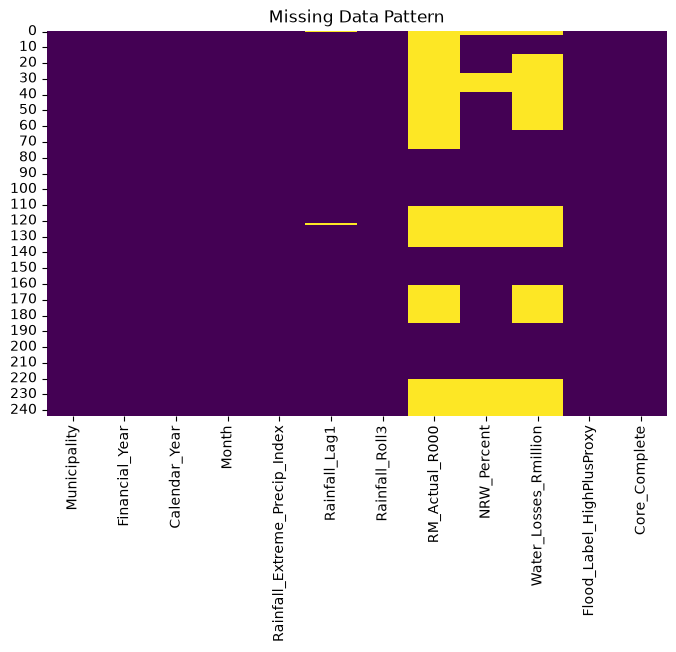

In [5]:
# see where the missing values are
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Pattern')
plt.show()

In [6]:
# only rows that have all the data needed for the model
df_core = df[df['Core_Complete'] == 'Y'].copy()
print("Rows after filtering:", df_core.shape)

Rows after filtering: (96, 12)


In [7]:
df_core.describe()

,Calendar_Year,Month,Rainfall_Extreme_Precip_Index,Rainfall_Lag1,Rainfall_Roll3,RM_Actual_R000,NRW_Percent,Water_Losses_Rmillion
count,96.000000,96.000000,96.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000
mean,2021.500000,6.500000,0.159792,0.162292,0.486458,2.501731e+06,45.343750,1977.150000
std,2.384158,3.470174,1.322267,1.318337,2.198039,1.532399e+06,9.673712,741.720055
min,2017.000000,1.000000,-0.780000,-0.780000,-1.930000,5.291930e+05,32.700000,714.000000
25%,2020.500000,3.750000,-0.600000,-0.600000,-1.347500,8.957810e+05,35.987500,1733.850000
50%,2022.000000,6.500000,-0.515000,-0.510000,0.035000,2.694029e+06,45.500000,2015.250000
75%,2023.000000,9.250000,0.187500,0.180000,1.345000,3.690508e+06,54.850000,2501.000000
max,2025.000000,12.000000,5.140000,5.140000,8.240000,4.832528e+06,58.200000,2900.100000


In [8]:
df_core.dtypes

Municipality                         str
Financial_Year                       str
Calendar_Year                      int64
Month                              int64
Rainfall_Extreme_Precip_Index    float64
Rainfall_Lag1                    float64
Rainfall_Roll3                   float64
RM_Actual_R000                   float64
NRW_Percent                      float64
Water_Losses_Rmillion            float64
Flood_Label_HighPlusProxy            str
Core_Complete                        str
dtype: object

In [9]:
# turn city name into a number, pick the columns for the model
df_model = df_core.copy()
df_model['Municipality_Code'] = df_model['Municipality'].map({'eThekwini': 0, 'Johannesburg': 1})

CORE_FEATURES = [
    'Rainfall_Extreme_Precip_Index',
    'Rainfall_Lag1',
    'Rainfall_Roll3',
    'RM_Actual_R000',
    'NRW_Percent',
    'Water_Losses_Rmillion',
    'Municipality_Code'
]
TARGET = 'Flood_Label_HighPlusProxy'

# drop rows with no rainfall lag (first month of each city has none)
print("Missing values before dropping:")
print(df_model[CORE_FEATURES].isnull().sum())

df_model = df_model.dropna(subset=CORE_FEATURES).reset_index(drop=True)

X = df_model[CORE_FEATURES]
y = df_model[TARGET].map({'N': 0, 'Y': 1})

print("\nFinal dataset shape:", df_model.shape)
print("Features shape:", X.shape)
print("Target counts:\n", y.value_counts())


Missing values before dropping:
Rainfall_Extreme_Precip_Index    0
Rainfall_Lag1                    0
Rainfall_Roll3                   0
RM_Actual_R000                   0
NRW_Percent                      0
Water_Losses_Rmillion            0
Municipality_Code                0
dtype: int64

Final dataset shape: (96, 13)
Features shape: (96, 7)
Target counts:
 Flood_Label_HighPlusProxy
0    85
1    11
Name: count, dtype: int64


Flood_Label_HighPlusProxy
N    85
Y    11
Name: count, dtype: int64
Flood_Label_HighPlusProxy
N    88.541667
Y    11.458333
Name: proportion, dtype: float64


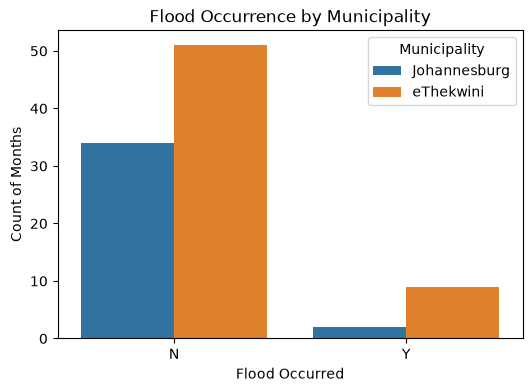

In [10]:
# flood vs non-flood months, by city
print(df_core['Flood_Label_HighPlusProxy'].value_counts())
print(df_core['Flood_Label_HighPlusProxy'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_core, x='Flood_Label_HighPlusProxy', hue='Municipality')
plt.title('Flood Occurrence by Municipality')
plt.xlabel('Flood Occurred')
plt.ylabel('Count of Months')
plt.show()

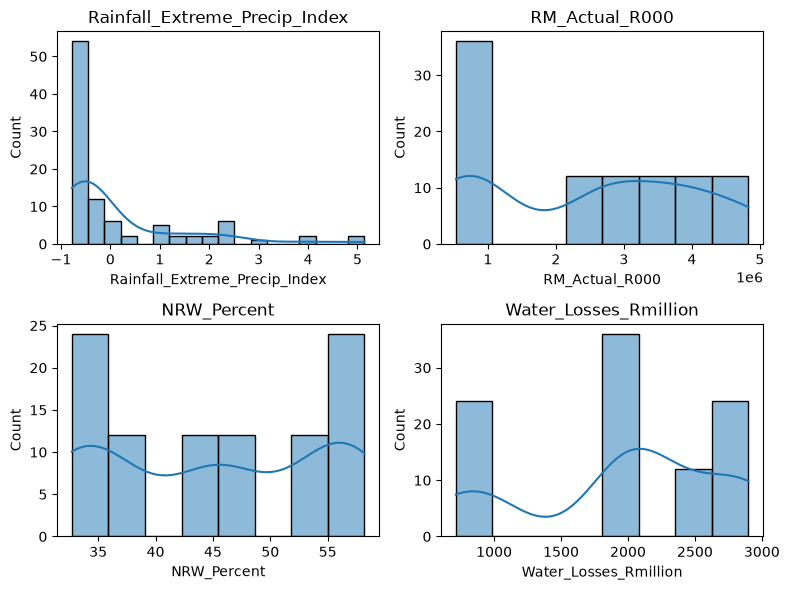

In [11]:
# distribution of the main numeric columns
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
core_num = ['Rainfall_Extreme_Precip_Index', 'RM_Actual_R000', 'NRW_Percent', 'Water_Losses_Rmillion']

for ax, col in zip(axes.flatten(), core_num):
    sns.histplot(df_core[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

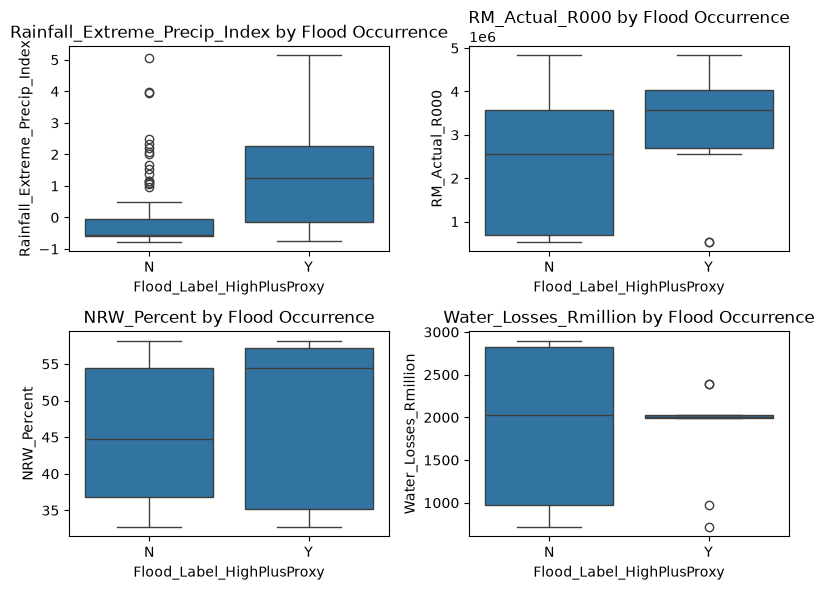

In [12]:
# compare each variable for flood vs non-flood months
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for ax, col in zip(axes.flatten(), core_num):
    sns.boxplot(data=df_core, x='Flood_Label_HighPlusProxy', y=col, ax=ax)
    ax.set_title(f'{col} by Flood Occurrence')

plt.tight_layout()
plt.show()

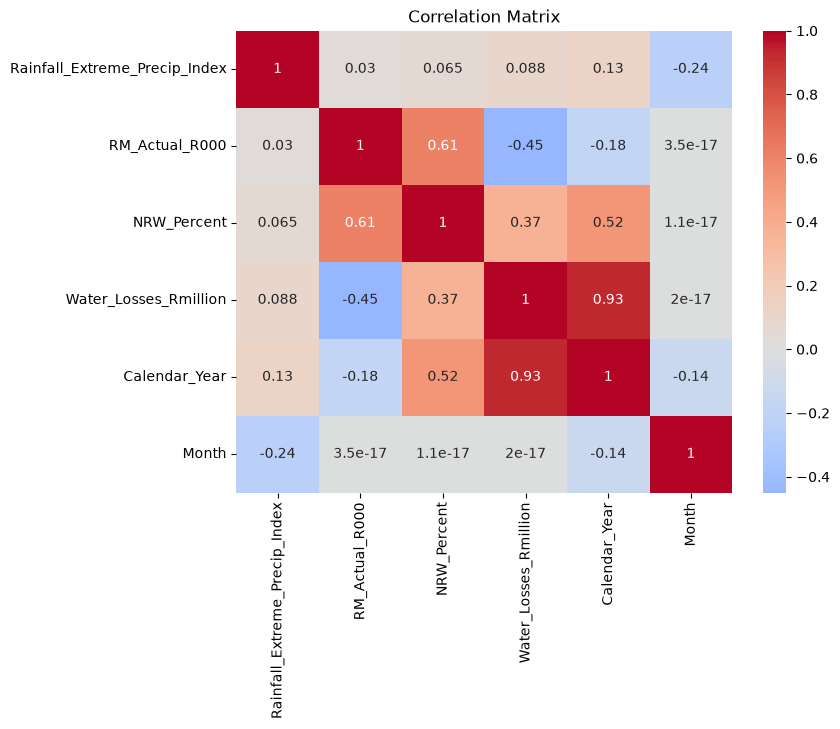

In [13]:
# check how the variables relate to each other
corr_cols = core_num + ['Calendar_Year', 'Month']
plt.figure(figsize=(8,6))
sns.heatmap(df_core[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

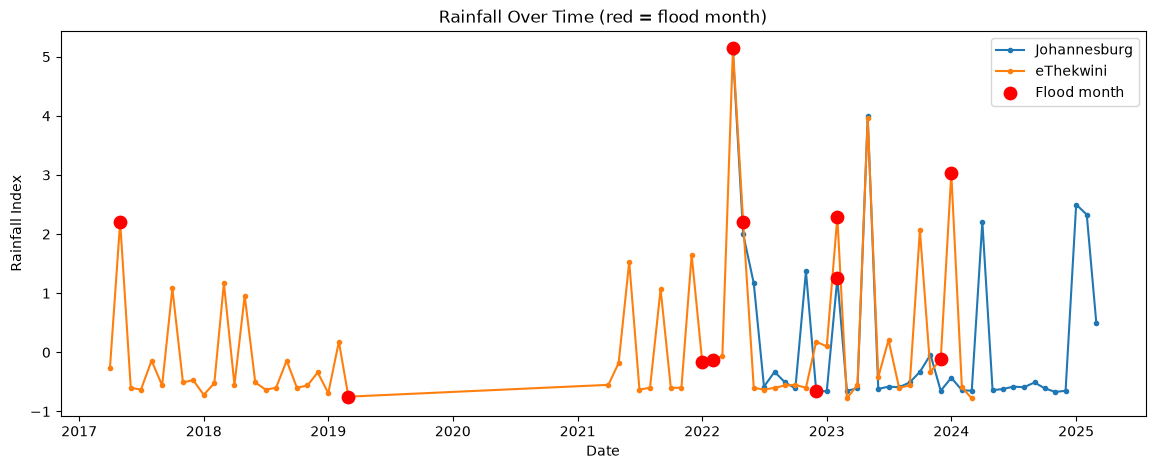

In [14]:
# rainfall over time, both cities, flood months marked in red
plt.figure(figsize=(14,5))
for city in df_core['Municipality'].unique():
    sub = df_core[df_core['Municipality']==city].sort_values(['Calendar_Year','Month'])
    dates = pd.to_datetime(sub['Calendar_Year'].astype(str) + '-' + sub['Month'].astype(str))
    plt.plot(dates, sub['Rainfall_Extreme_Precip_Index'], label=city, marker='o', markersize=3)

flood_months = df_core[df_core['Flood_Label_HighPlusProxy']=='Y']
flood_dates = pd.to_datetime(flood_months['Calendar_Year'].astype(str) + '-' + flood_months['Month'].astype(str))
plt.scatter(flood_dates, flood_months['Rainfall_Extreme_Precip_Index'], color='red', s=80, zorder=5, label='Flood month')

plt.legend()
plt.title('Rainfall Over Time (red = flood month)')
plt.xlabel('Date')
plt.ylabel('Rainfall Index')
plt.show()

In [15]:
# flood months where rainfall was actually low that month
low_rain_floods = df_core[(df_core['Flood_Label_HighPlusProxy']=='Y') & 
                            (df_core['Rainfall_Extreme_Precip_Index'] < 0)]
print(low_rain_floods[['Municipality','Calendar_Year','Month','Rainfall_Extreme_Precip_Index']])


     Municipality  Calendar_Year  Month  Rainfall_Extreme_Precip_Index
83   Johannesburg           2022     12                          -0.65
160     eThekwini           2019      3                          -0.75
194     eThekwini           2022      1                          -0.16
195     eThekwini           2022      2                          -0.13
217     eThekwini           2023     12                          -0.12


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, "| Train flood count:", y_train.sum())
print("Test shape:", X_test.shape, "| Test flood count:", y_test.sum())

Train shape: (72, 7) | Train flood count: 8
Test shape: (24, 7) | Test flood count: 3


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_baseline.fit(X_train, y_train)
y_pred = rf_baseline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Flood','Flood']))

              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        21
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        24
   macro avg       0.98      0.83      0.89        24
weighted avg       0.96      0.96      0.95        24



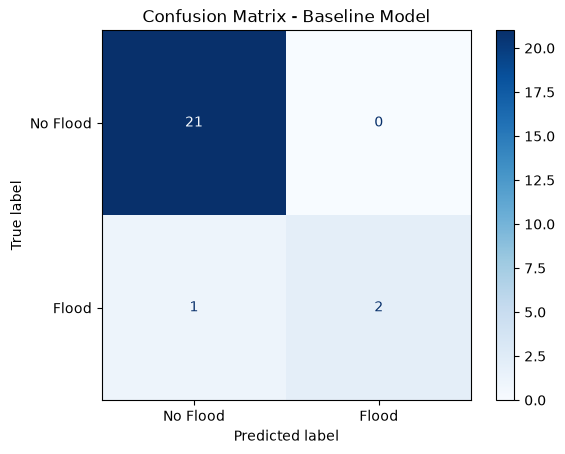

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Flood','Flood'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.show()

Rainfall_Extreme_Precip_Index    0.315525
Rainfall_Lag1                    0.267155
Rainfall_Roll3                   0.183876
Water_Losses_Rmillion            0.081189
RM_Actual_R000                   0.070212
NRW_Percent                      0.057415
Municipality_Code                0.024629
dtype: float64


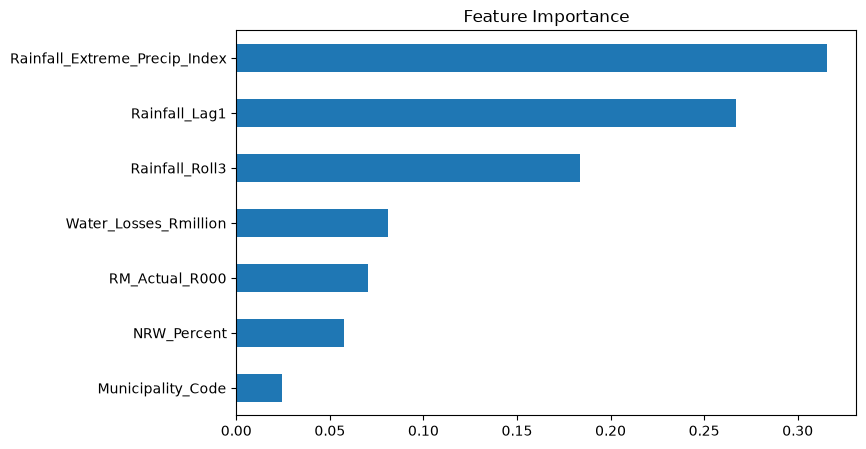

In [19]:
importances = pd.Series(rf_baseline.feature_importances_, index=CORE_FEATURES).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# test on 5 different splits instead of just one, so results are more reliable
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(rf_cv, X, y, cv=skf, scoring=scoring)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric.capitalize():10s}: mean={scores.mean():.3f}, std={scores.std():.3f}, folds={np.round(scores,2)}")

c:\Users\Admin\Desktop\Capstone Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy  : mean=0.896, std=0.045, folds=[0.85 0.84 0.95 0.89 0.95]
Precision : mean=0.433, std=0.389, folds=[0.   0.   1.   0.5  0.67]
Recall    : mean=0.500, std=0.447, folds=[0.  0.  0.5 1.  1. ]
F1        : mean=0.427, std=0.352, folds=[0.   0.   0.67 0.67 0.8 ]


In [21]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba = cross_val_predict(rf_cv, X, y, cv=skf, method='predict_proba')[:,1]

#different cutoff points to find the best balance
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    p = precision_score(y, y_pred_thresh, zero_division=0)
    r = recall_score(y, y_pred_thresh, zero_division=0)
    f = f1_score(y, y_pred_thresh, zero_division=0)
    print(f"Threshold {threshold}: precision={p:.2f}, recall={r:.2f}, f1={f:.2f}")

Threshold 0.5: precision=0.56, recall=0.45, f1=0.50
Threshold 0.4: precision=0.36, recall=0.45, f1=0.40
Threshold 0.3: precision=0.32, recall=0.55, f1=0.40
Threshold 0.2: precision=0.21, recall=0.73, f1=0.33
Threshold 0.1: precision=0.14, recall=0.73, f1=0.24


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

cv_results_lr = cross_validate(log_reg, X, y, cv=skf, scoring=scoring)
for metric in scoring:
    scores = cv_results_lr[f'test_{metric}']
    print(f"{metric.capitalize():10s}: mean={scores.mean():.3f}, std={scores.std():.3f}")

Accuracy  : mean=0.730, std=0.080
Precision : mean=0.184, std=0.108
Recall    : mean=0.467, std=0.323
F1        : mean=0.254, std=0.141


In [36]:
from xgboost import XGBClassifier

# XGBoost is another tree-based model, like Random Forest.
# The difference: Random Forest builds all its trees separately and votes,
# while XGBoost builds trees one after another, each one trying to fix
# the mistakes of the one before it.

# floods are rare, so we tell XGBoost to pay more attention to them.
# this works out to 85 non-flood months divided by 11 flood months
scale_weight = (y == 0).sum() / (y == 1).sum()
print("scale_pos_weight =", round(scale_weight, 2))

xgb_cv = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

# same 5 test groups as the other two models, so the comparison is fair
cv_results_xgb = cross_validate(xgb_cv, X, y, cv=skf, scoring=scoring)

for metric in scoring:
    scores = cv_results_xgb[f'test_{metric}']
    print(f"{metric.capitalize():10s}: mean={scores.mean():.3f}, std={scores.std():.3f}, folds={np.round(scores,2)}")

scale_pos_weight = 7.73


c:\Users\Admin\Desktop\Capstone Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Desktop\Capstone Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy  : mean=0.856, std=0.085, folds=[0.7  0.89 0.89 0.84 0.95]
Precision : mean=0.213, std=0.275, folds=[0.   0.   0.   0.4  0.67]
Recall    : mean=0.400, std=0.490, folds=[0. 0. 0. 1. 1.]
F1        : mean=0.274, std=0.344, folds=[0.   0.   0.   0.57 0.8 ]


In [37]:
# try different cut-off points, same as we did for Random Forest
y_proba_xgb = cross_val_predict(xgb_cv, X, y, cv=skf, method='predict_proba')[:,1]

for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_thresh = (y_proba_xgb >= threshold).astype(int)
    p = precision_score(y, y_pred_thresh, zero_division=0)
    r = recall_score(y, y_pred_thresh, zero_division=0)
    f = f1_score(y, y_pred_thresh, zero_division=0)
    print(f"Threshold {threshold}: precision={p:.2f}, recall={r:.2f}, f1={f:.2f}")

Threshold 0.5: precision=0.36, recall=0.36, f1=0.36
Threshold 0.4: precision=0.31, recall=0.36, f1=0.33
Threshold 0.3: precision=0.25, recall=0.36, f1=0.30
Threshold 0.2: precision=0.28, recall=0.45, f1=0.34
Threshold 0.1: precision=0.23, recall=0.45, f1=0.30


              precision    recall  f1-score   support

    No Flood       0.92      0.89      0.90        85
       Flood       0.31      0.36      0.33        11

    accuracy                           0.83        96
   macro avg       0.61      0.63      0.62        96
weighted avg       0.85      0.83      0.84        96



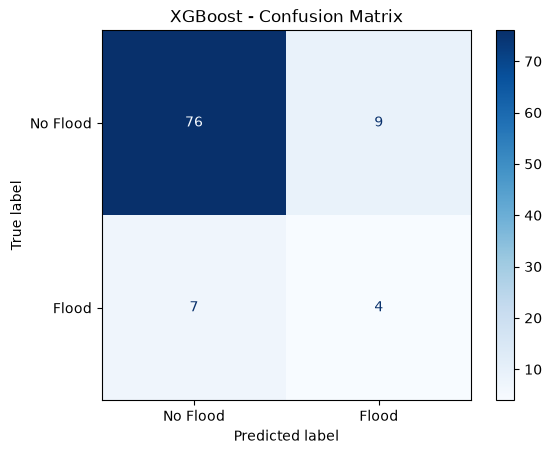

In [38]:
# XGBoost results at the same 0.4 cut-off used for Random Forest
y_pred_xgb = (y_proba_xgb >= 0.4).astype(int)

print(classification_report(y, y_pred_xgb, target_names=['No Flood','Flood']))

cm_xgb = confusion_matrix(y, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Flood','Flood'])
disp.plot(cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.show()

Rainfall_Lag1                    0.309793
RM_Actual_R000                   0.230095
Rainfall_Extreme_Precip_Index    0.227493
Water_Losses_Rmillion            0.100692
Rainfall_Roll3                   0.090132
NRW_Percent                      0.041796
Municipality_Code                0.000000
dtype: float32


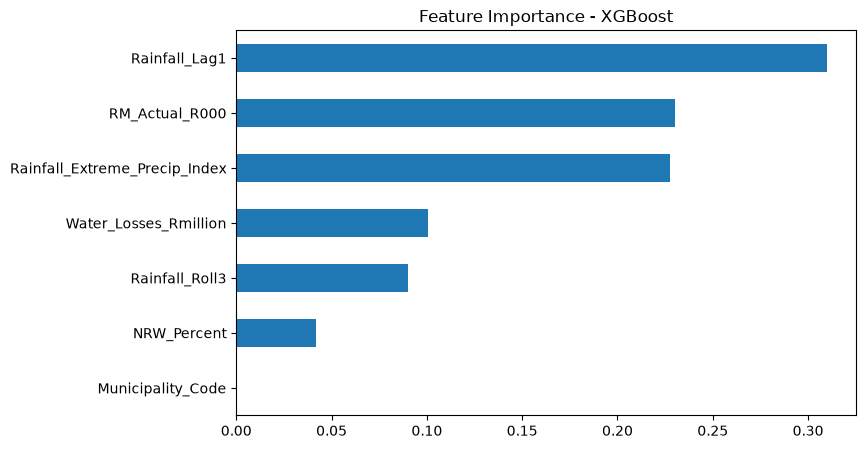

In [39]:
# which features did XGBoost rely on most?
xgb_cv.fit(X, y)
importances_xgb = pd.Series(xgb_cv.feature_importances_, index=CORE_FEATURES).sort_values(ascending=False)
print(importances_xgb)

plt.figure(figsize=(8,5))
importances_xgb.plot(kind='barh')
plt.title('Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.show()

              precision    recall  f1-score   support

    No Flood       0.93      0.89      0.91        85
       Flood       0.36      0.45      0.40        11

    accuracy                           0.84        96
   macro avg       0.64      0.67      0.66        96
weighted avg       0.86      0.84      0.85        96



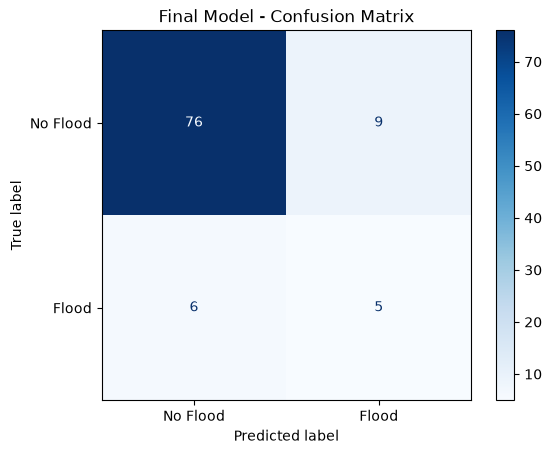

In [23]:
# final model, threshold set to 0.4
final_threshold = 0.4

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

y_proba_cv = cross_val_predict(rf_final, X, y, cv=skf, method='predict_proba')[:,1]
y_pred_final = (y_proba_cv >= final_threshold).astype(int)

print(classification_report(y, y_pred_final, target_names=['No Flood','Flood']))

cm_final = confusion_matrix(y, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['No Flood','Flood'])
disp.plot(cmap='Blues')
plt.title('Final Model - Confusion Matrix')
plt.show()

In [24]:
# which flood months did the model miss?
missed = df_model[(y.values==1) & (y_pred_final==0)]
print(missed[['Municipality','Financial_Year','Month','Rainfall_Extreme_Precip_Index','Rainfall_Lag1']])

    Municipality Financial_Year  Month  Rainfall_Extreme_Precip_Index  \
8   Johannesburg        2022/23     12                          -0.65   
10  Johannesburg        2022/23      2                           1.25   
37     eThekwini        2017/18      5                           2.21   
59     eThekwini        2018/19      3                          -0.75   
69     eThekwini        2021/22      1                          -0.16   
92     eThekwini        2023/24     12                          -0.12   

    Rainfall_Lag1  
8            1.37  
10          -0.66  
37          -0.27  
59           0.18  
69           1.65  
92          -0.33  


In [40]:
# put all three models in one table for easy comparison
comparison = pd.DataFrame({
    'Logistic Regression': [cv_results_lr[f'test_{m}'].mean() for m in scoring],
    'Random Forest': [cv_results[f'test_{m}'].mean() for m in scoring],
    'XGBoost': [cv_results_xgb[f'test_{m}'].mean() for m in scoring]
}, index=[m.capitalize() for m in scoring])

print(comparison.round(3))

           Logistic Regression  Random Forest  XGBoost
Accuracy                 0.730          0.896    0.856
Precision                0.184          0.433    0.213
Recall                   0.467          0.500    0.400
F1                       0.254          0.427    0.274


In [25]:
# get the model's predicted flood probability for each month
df_model['P_Flood_Model'] = cross_val_predict(rf_final, X, y, cv=skf, method='predict_proba')[:,1]

print(df_model[['Municipality','Financial_Year','Month','P_Flood_Model']].sort_values('P_Flood_Model', ascending=False).head(10))

    Municipality Financial_Year  Month  P_Flood_Model
70     eThekwini        2021/22      2          0.860
93     eThekwini        2023/24      1          0.835
82     eThekwini        2022/23      2          0.820
11  Johannesburg        2022/23      3          0.805
72     eThekwini        2022/23      4          0.755
62     eThekwini        2021/22      6          0.700
73     eThekwini        2022/23      5          0.670
7   Johannesburg        2022/23     11          0.615
87     eThekwini        2023/24      7          0.615
81     eThekwini        2022/23      1          0.455


In [26]:
# flood damage figures from EM-DAT (in thousands of US dollars)
severity_data = pd.DataFrame([
    {'City':'Johannesburg','Damage_USD_000': 100000},
    {'City':'Johannesburg','Damage_USD_000': 75000},
    {'City':'eThekwini','Damage_USD_000': 180000},
    {'City':'eThekwini','Damage_USD_000': 100000},
    {'City':'eThekwini','Damage_USD_000': 50000},
    {'City':'eThekwini','Damage_USD_000': 105000},
    {'City':'eThekwini','Damage_USD_000': 3500000},
    {'City':'eThekwini','Damage_USD_000': 10000},
])

# median instead of mean, so the one huge 2022 flood doesn't skew things
severity_by_city_usd = severity_data.groupby('City')['Damage_USD_000'].median()
USD_TO_ZAR = 16.7
severity_by_city_zar_million = (severity_by_city_usd * 1000 * USD_TO_ZAR) / 1_000_000

print("Severity per flood event (R million):")
print(severity_by_city_zar_million)

Severity per flood event (R million):
City
Johannesburg    1461.25
eThekwini       1711.75
Name: Damage_USD_000, dtype: float64


In [27]:
# how often each city has flooded historically - this is what traditional pricing uses
historical_freq = df_model.groupby('Municipality')['Flood_Label_HighPlusProxy'].apply(
    lambda x: (x == 'Y').mean()
)
print("Historical flood frequency per city:")
print(historical_freq)

Historical flood frequency per city:
Municipality
Johannesburg    0.055556
eThekwini       0.150000
Name: Flood_Label_HighPlusProxy, dtype: float64


In [28]:
df_model['Severity_Rmillion'] = df_model['Municipality'].map(severity_by_city_zar_million)
df_model['Historical_Frequency'] = df_model['Municipality'].map(historical_freq)

# premium = frequency x severity
# integrated: frequency changes every month, based on the model
df_model['Integrated_Pure_Premium_Rmillion'] = df_model['P_Flood_Model'] * df_model['Severity_Rmillion']

# traditional: frequency is fixed at the historical average
df_model['Traditional_Pure_Premium_Rmillion'] = df_model['Historical_Frequency'] * df_model['Severity_Rmillion']

print(df_model[['Municipality','Financial_Year','Month','P_Flood_Model','Historical_Frequency',
                 'Integrated_Pure_Premium_Rmillion','Traditional_Pure_Premium_Rmillion']].sort_values(
                 'Integrated_Pure_Premium_Rmillion', ascending=False).head(10))

    Municipality Financial_Year  Month  P_Flood_Model  Historical_Frequency  \
70     eThekwini        2021/22      2          0.860              0.150000   
93     eThekwini        2023/24      1          0.835              0.150000   
82     eThekwini        2022/23      2          0.820              0.150000   
72     eThekwini        2022/23      4          0.755              0.150000   
62     eThekwini        2021/22      6          0.700              0.150000   
11  Johannesburg        2022/23      3          0.805              0.055556   
73     eThekwini        2022/23      5          0.670              0.150000   
87     eThekwini        2023/24      7          0.615              0.150000   
7   Johannesburg        2022/23     11          0.615              0.055556   
81     eThekwini        2022/23      1          0.455              0.150000   

    Integrated_Pure_Premium_Rmillion  Traditional_Pure_Premium_Rmillion  
70                        1472.10500                    

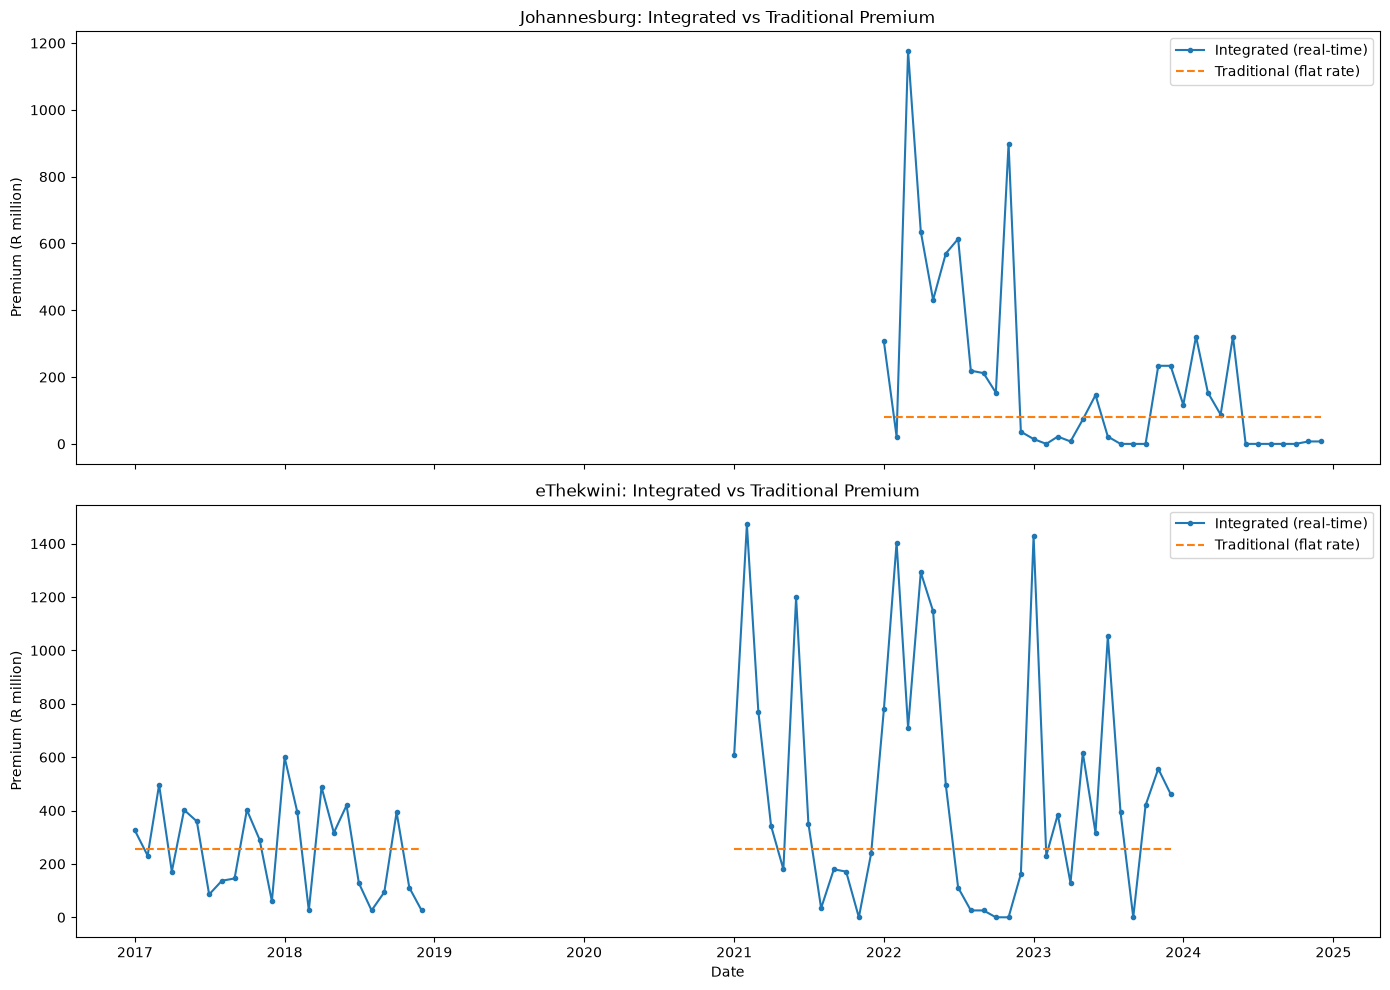

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14,10), sharex=True)

for i, city in enumerate(df_model['Municipality'].unique()):
    sub = df_model[df_model['Municipality']==city].sort_values(['Financial_Year','Month']).copy()
    sub['Date'] = pd.to_datetime(sub['Financial_Year'].str[:4].astype(int).astype(str) + '-' + sub['Month'].astype(str))
    
    # fill in missing months so the line doesn't join across gaps
    full_range = pd.date_range(sub['Date'].min(), sub['Date'].max(), freq='MS')
    sub = sub.set_index('Date').reindex(full_range)
    
    axes[i].plot(sub.index, sub['Integrated_Pure_Premium_Rmillion'], label='Integrated (real-time)', marker='o', markersize=3)
    axes[i].plot(sub.index, sub['Traditional_Pure_Premium_Rmillion'], label='Traditional (flat rate)', linestyle='--')
    axes[i].set_title(f'{city}: Integrated vs Traditional Premium')
    axes[i].set_ylabel('Premium (R million)')
    axes[i].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [30]:
# how far off is traditional pricing, in both directions?
df_model['Premium_Gap_Rmillion'] = df_model['Integrated_Pure_Premium_Rmillion'] - df_model['Traditional_Pure_Premium_Rmillion']

underpriced = df_model[df_model['Premium_Gap_Rmillion'] > 0].sort_values('Premium_Gap_Rmillion', ascending=False)
print(underpriced[['Municipality','Financial_Year','Month','Integrated_Pure_Premium_Rmillion','Traditional_Pure_Premium_Rmillion','Premium_Gap_Rmillion']].head(5))
print(f"\nMonths under-priced by traditional model: {len(underpriced)} of {len(df_model)} ({len(underpriced)/len(df_model)*100:.1f}%)")
print(f"Average under-pricing gap (R million): {underpriced['Premium_Gap_Rmillion'].mean():.1f}")

overpriced = df_model[df_model['Premium_Gap_Rmillion'] < 0]
print(f"\nMonths over-priced by traditional model: {len(overpriced)} of {len(df_model)} ({len(overpriced)/len(df_model)*100:.1f}%)")
print(f"Average over-pricing gap (R million): {overpriced['Premium_Gap_Rmillion'].mean():.1f}")

    Municipality Financial_Year  Month  Integrated_Pure_Premium_Rmillion  \
70     eThekwini        2021/22      2                        1472.10500   
93     eThekwini        2023/24      1                        1429.31125   
82     eThekwini        2022/23      2                        1403.63500   
11  Johannesburg        2022/23      3                        1176.30625   
72     eThekwini        2022/23      4                        1292.37125   

    Traditional_Pure_Premium_Rmillion  Premium_Gap_Rmillion  
70                         256.762500           1215.342500  
93                         256.762500           1172.548750  
82                         256.762500           1146.872500  
11                          81.180556           1095.125694  
72                         256.762500           1035.608750  

Months under-priced by traditional model: 51 of 96 (53.1%)
Average under-pricing gap (R million): 352.7

Months over-priced by traditional model: 45 of 96 (46.9%)
Average

In [31]:
# does the integrated premium actually flag real flood months?
flood_months_df = df_model[df_model['Flood_Label_HighPlusProxy']=='Y']
caught = (flood_months_df['Integrated_Pure_Premium_Rmillion'] > flood_months_df['Traditional_Pure_Premium_Rmillion']).sum()
total_floods = len(flood_months_df)
print(f"Of {total_floods} flood months, integrated premium was higher in {caught} ({caught/total_floods*100:.1f}%)")

print(f"\nTotal Integrated premium (R million): {df_model['Integrated_Pure_Premium_Rmillion'].sum():.1f}")
print(f"Total Traditional premium (R million): {df_model['Traditional_Pure_Premium_Rmillion'].sum():.1f}")

Of 11 flood months, integrated premium was higher in 8 (72.7%)

Total Integrated premium (R million): 30862.2
Total Traditional premium (R million): 18328.2


In [32]:
# --- Objective 3: Compare the integrated model against an existing pricing method ---
# Our literature review names Generalized Linear Models (GLM) as one of the 
# leading current insurance pricing approaches in South Africa. Logistic 
# Regression is a GLM, so we use it here as the "existing method" benchmark.

# get Logistic Regression's flood probability for each month, same way we did for Random Forest
df_model['P_Flood_LogReg'] = cross_val_predict(log_reg, X, y, cv=skf, method='predict_proba')[:,1]

# apply the same pure premium formula, just swapping in the GLM's probability
df_model['GLM_Pure_Premium_Rmillion'] = df_model['P_Flood_LogReg'] * df_model['Severity_Rmillion']

print(df_model[['Municipality','Financial_Year','Month',
                 'Traditional_Pure_Premium_Rmillion',
                 'GLM_Pure_Premium_Rmillion',
                 'Integrated_Pure_Premium_Rmillion']].sort_values(
                 'Integrated_Pure_Premium_Rmillion', ascending=False).head(10))

    Municipality Financial_Year  Month  Traditional_Pure_Premium_Rmillion  \
70     eThekwini        2021/22      2                         256.762500   
93     eThekwini        2023/24      1                         256.762500   
82     eThekwini        2022/23      2                         256.762500   
72     eThekwini        2022/23      4                         256.762500   
62     eThekwini        2021/22      6                         256.762500   
11  Johannesburg        2022/23      3                          81.180556   
73     eThekwini        2022/23      5                         256.762500   
87     eThekwini        2023/24      7                         256.762500   
7   Johannesburg        2022/23     11                          81.180556   
81     eThekwini        2022/23      1                         256.762500   

    GLM_Pure_Premium_Rmillion  Integrated_Pure_Premium_Rmillion  
70                 558.389534                        1472.10500  
93                13

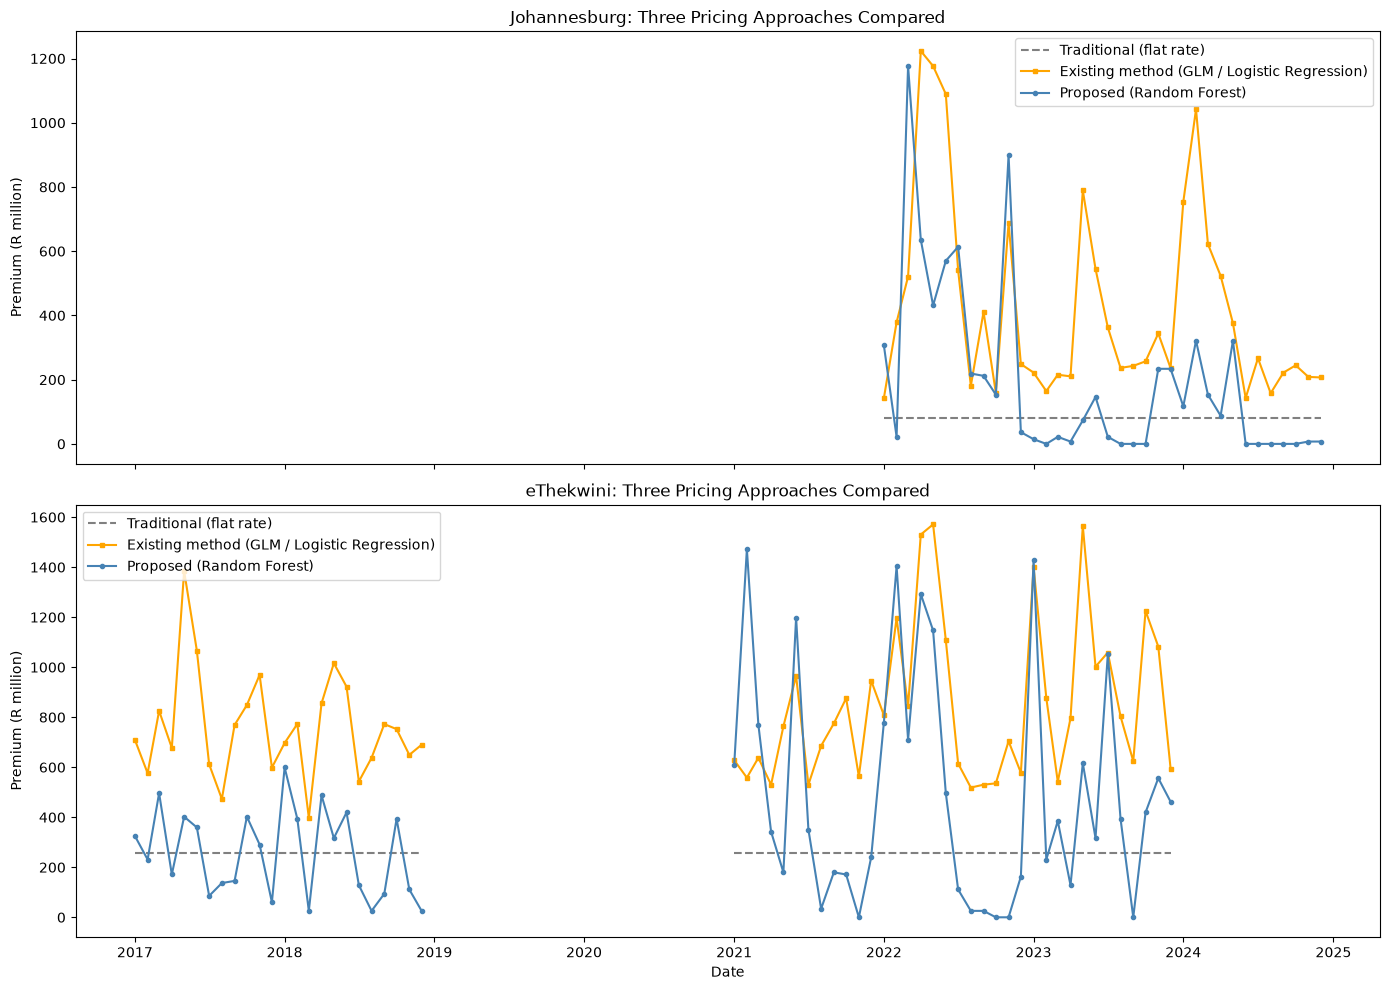

In [33]:
# --- Chart: all three approaches side by side ---
fig, axes = plt.subplots(2, 1, figsize=(14,10), sharex=True)

for i, city in enumerate(df_model['Municipality'].unique()):
    sub = df_model[df_model['Municipality']==city].sort_values(['Financial_Year','Month']).copy()
    sub['Date'] = pd.to_datetime(sub['Financial_Year'].str[:4].astype(int).astype(str) + '-' + sub['Month'].astype(str))
    full_range = pd.date_range(sub['Date'].min(), sub['Date'].max(), freq='MS')
    sub = sub.set_index('Date').reindex(full_range)

    axes[i].plot(sub.index, sub['Traditional_Pure_Premium_Rmillion'], label='Traditional (flat rate)', linestyle='--', color='gray')
    axes[i].plot(sub.index, sub['GLM_Pure_Premium_Rmillion'], label='Existing method (GLM / Logistic Regression)', marker='s', markersize=3, color='orange')
    axes[i].plot(sub.index, sub['Integrated_Pure_Premium_Rmillion'], label='Proposed (Random Forest)', marker='o', markersize=3, color='steelblue')
    axes[i].set_title(f'{city}: Three Pricing Approaches Compared')
    axes[i].set_ylabel('Premium (R million)')
    axes[i].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [34]:
# --- Does the proposed model actually catch more real flood months than the existing GLM method? ---
flood_months_df = df_model[df_model['Flood_Label_HighPlusProxy']=='Y']

caught_by_rf = (flood_months_df['Integrated_Pure_Premium_Rmillion'] > flood_months_df['Traditional_Pure_Premium_Rmillion']).sum()
caught_by_glm = (flood_months_df['GLM_Pure_Premium_Rmillion'] > flood_months_df['Traditional_Pure_Premium_Rmillion']).sum()
total_floods = len(flood_months_df)

print(f"Of {total_floods} real flood months:")
print(f"  Proposed model (Random Forest) correctly priced above baseline in {caught_by_rf} ({caught_by_rf/total_floods*100:.1f}%)")
print(f"  Existing method (GLM) correctly priced above baseline in {caught_by_glm} ({caught_by_glm/total_floods*100:.1f}%)")

print(f"\nTotal premium collected, whole study period (R million):")
print(f"  Traditional:  {df_model['Traditional_Pure_Premium_Rmillion'].sum():.1f}")
print(f"  Existing GLM: {df_model['GLM_Pure_Premium_Rmillion'].sum():.1f}")
print(f"  Proposed RF:  {df_model['Integrated_Pure_Premium_Rmillion'].sum():.1f}")

Of 11 real flood months:
  Proposed model (Random Forest) correctly priced above baseline in 8 (72.7%)
  Existing method (GLM) correctly priced above baseline in 11 (100.0%)

Total premium collected, whole study period (R million):
  Traditional:  18328.2
  Existing GLM: 64134.9
  Proposed RF:  30862.2


In [35]:
# --- Does GLM stay elevated even during calm, non-flood months? ---
non_flood = df_model[df_model['Flood_Label_HighPlusProxy']=='N']

print("Average premium during NON-flood months (R million):")
print(f"  Traditional:  {non_flood['Traditional_Pure_Premium_Rmillion'].mean():.1f}")
print(f"  Existing GLM: {non_flood['GLM_Pure_Premium_Rmillion'].mean():.1f}")
print(f"  Proposed RF:  {non_flood['Integrated_Pure_Premium_Rmillion'].mean():.1f}")

Average premium during NON-flood months (R million):
  Traditional:  186.5
  Existing GLM: 638.2
  Proposed RF:  265.4
